In [1]:
# Config & imports

import os
import numpy as np
import pandas as pd

# Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# I/O
DATA_PATH = "./data/train_mp.csv"
os.makedirs("./visual", exist_ok=True)

# Columns to exclude from features (same as your RF/XGB scripts)
NON_FEATURE_COLS = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# Class names for plots
CLASS_NAMES = ["C", "SC"]  # 0, 1


2026-01-23 09:15:49.145447: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 09:15:49.383621: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 09:15:50.337156: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Load data & define classes from band_gap

df = pd.read_csv(DATA_PATH)

# Features: all except excluded, numeric only
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# Binary labels from band_gap
bg = pd.to_numeric(df["band_gap"], errors="coerce")
tol = 1e-8
y_all = pd.Series(np.nan, index=bg.index, dtype="float64")
y_all[(bg >= 0.1) & (bg <= 3.0)] = 1  # semiconductor
y_all[np.abs(bg - 0.0) <= tol] = 0    # conductor

mask_valid = y_all.notna()
print(f"Total rows: {len(df)} | Kept (classified): {mask_valid.sum()} | Dropped (outside spec): {(~mask_valid).sum()}")

X_all = X_all.loc[mask_valid].reset_index(drop=True)
y_all = y_all.loc[mask_valid].astype(int).reset_index(drop=True)

print("Class counts:", dict(zip(*np.unique(y_all, return_counts=True))))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])


Total rows: 6419 | Kept (classified): 5584 | Dropped (outside spec): 835
Class counts: {0: 3340, 1: 2244}
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


In [3]:
# Split, impute, scale, class weights

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

# Median imputation
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

# Standardize (fit on train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype("float32")
X_test_s  = scaler.transform(X_test).astype("float32")

print("train shape:", X_train_s.shape, "| test shape:", X_test_s.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("test  class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

# Class weights (useful if imbalanced)
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(k): float(v) for k, v in zip(classes, cw)}
print("class_weight:", class_weight)


train shape: (4467, 250) | test shape: (1117, 250)
train class counts: {0: 2672, 1: 1795}
test  class counts: {0: 668, 1: 449}
class_weight: {0: 0.8358907185628742, 1: 1.2442896935933148}


In [4]:
# Build the MLP (binary classifier)

def build_mlp(n_in: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(n_in,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(64,  activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(1,   activation="sigmoid")  # binary
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall"),
                 keras.metrics.AUC(name="auc")]
    )
    return model

mlp = build_mlp(X_train_s.shape[1])
mlp.summary()


2026-01-23 09:16:01.855656: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2322] Ignoring visible gpu device (device: 4, name: NVIDIA T400 4GB, pci bus id: 0000:e3:00.0, compute capability: 7.5) with core count: 6. The minimum required count is 8. You can adjust this requirement with the env var TF_MIN_GPU_MULTIPROCESSOR_COUNT.
2026-01-23 09:16:02.355924: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14641 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:31:00.0, compute capability: 8.6
2026-01-23 09:16:02.356738: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 20387 MB memory:  -> device: 1, name: NVIDIA RTX A5000, pci bus id: 0000:4b:00.0, compute capability: 8.6
2026-01-23 09:16:02.357332: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 2038

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        64,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,473 (412.00 KB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train & save

EPOCHS = 300
BATCH_SIZE = 256
PATIENCE = 30

es  = callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(5, PATIENCE//3), min_lr=1e-6)

history = mlp.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    class_weight=class_weight,
    callbacks=[es, rlr]
)


Epoch 1/300


I0000 00:00:1769127368.923307 1218657 service.cc:145] XLA service 0x7f97b4005400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769127368.923384 1218657 service.cc:153]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1769127368.923393 1218657 service.cc:153]   StreamExecutor device (1): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1769127368.923398 1218657 service.cc:153]   StreamExecutor device (2): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1769127368.923403 1218657 service.cc:153]   StreamExecutor device (3): NVIDIA RTX A5000, Compute Capability 8.6
2026-01-23 09:16:08.990118: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-23 09:16:09.242183: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1769127370.809611 121

 1/14 ━━━━━━━━━━━━━━━━━━━━ 1:14 6s/step - auc: 0.5759 - loss: 0.6968 - precision: 0.4762 - recall: 0.2830

I0000 00:00:1769127373.165575 1218657 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1769127374.416002 1218914 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_273', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1769127374.780475 1218940 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_571', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1769127374.903353 1218929 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_300', 60 bytes spill stores, 60 bytes spill loads

I0000 00:00:1769127374.991190 1218947 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_571', 128 bytes spill stores, 128 bytes spill loads

I0000 00:00:1769127375.097464 1218941 asm_compiler.cc:369] ptxas warning :

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - auc: 0.7903 - loss: 0.5562 - precision: 0.6553 - recall: 0.6566

I0000 00:00:1769127379.043685 1219196 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_96', 4 bytes spill stores, 4 bytes spill loads



14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 525ms/step - auc: 0.8530 - loss: 0.4826 - precision: 0.7022 - recall: 0.7498 - val_auc: 0.9014 - val_loss: 0.4013 - val_precision: 0.7506 - val_recall: 0.8599 - learning_rate: 0.0010
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.9113 - loss: 0.3782 - precision: 0.7532 - recall: 0.8721 - val_auc: 0.9155 - val_loss: 0.3677 - val_precision: 0.7714 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9245 - loss: 0.3486 - precision: 0.7633 - recall: 0.8833 - val_auc: 0.9230 - val_loss: 0.3490 - val_precision: 0.7925 - val_recall: 0.8709 - learning_rate: 0.0010
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9351 - loss: 0.3249 - precision: 0.7778 - recall: 0.9050 - val_auc: 0.9251 - val_loss: 0.3434 - val_precision: 0.8100 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.9439 - loss: 0.3031 - precision: 0.7883 - recall: 0.9

In [6]:
# Save model + scaler stats
os.makedirs("./model_mlp_cls", exist_ok=True)
mlp.save("./model_mlp_cls/ann_mlp_cls.keras")
np.savez("./model_mlp_cls/scaler_mean_std.npz",
         mean=scaler.mean_, scale=scaler.scale_, var=scaler.var_)


In [7]:
# Evaluation (metrics + text report)

def summarize_classification(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"{label} Acc: {acc:.3f} | P: {p:.3f} | R: {r:.3f} | F1: {f1:.3f}")
    print("\nClassification report:\n",
          classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return acc, p, r, f1

# Probabilities → class labels with 0.5 threshold
yhat_tr_prob = mlp.predict(X_train_s, verbose=0).ravel()
yhat_te_prob = mlp.predict(X_test_s,  verbose=0).ravel()
yhat_tr = (yhat_tr_prob >= 0.5).astype(int)
yhat_te = (yhat_te_prob >= 0.5).astype(int)

print("== training ==")
tr_metrics = summarize_classification(y_train, yhat_tr, "Train")

print("\n== test ==")
te_metrics = summarize_classification(y_test, yhat_te, "Test")


== training ==
Train Acc: 0.875 | P: 0.868 | R: 0.876 | F1: 0.871

Classification report:
               precision    recall  f1-score   support

           C       0.92      0.87      0.89      2672
          SC       0.82      0.88      0.85      1795

    accuracy                           0.87      4467
   macro avg       0.87      0.88      0.87      4467
weighted avg       0.88      0.87      0.88      4467


== test ==
Test Acc: 0.847 | P: 0.840 | R: 0.845 | F1: 0.842

Classification report:
               precision    recall  f1-score   support

           C       0.88      0.86      0.87       668
          SC       0.80      0.83      0.81       449

    accuracy                           0.85      1117
   macro avg       0.84      0.84      0.84      1117
weighted avg       0.85      0.85      0.85      1117



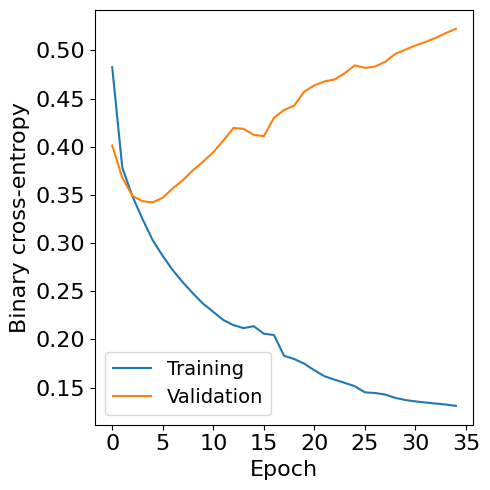

In [8]:
# Learning curve (loss vs epoch)

plt.figure(figsize=(5,5))
plt.plot(history.history["loss"],     label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Binary cross-entropy", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('./visual/fig_s2d.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


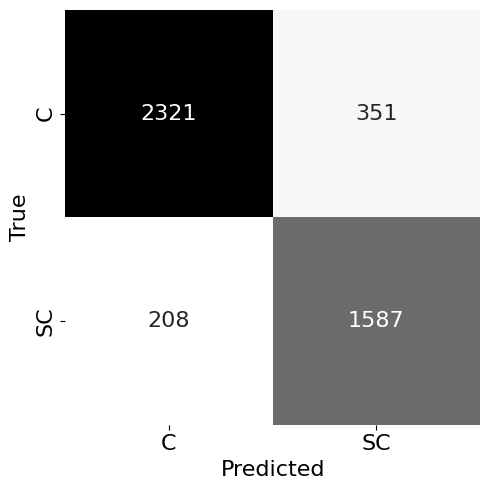

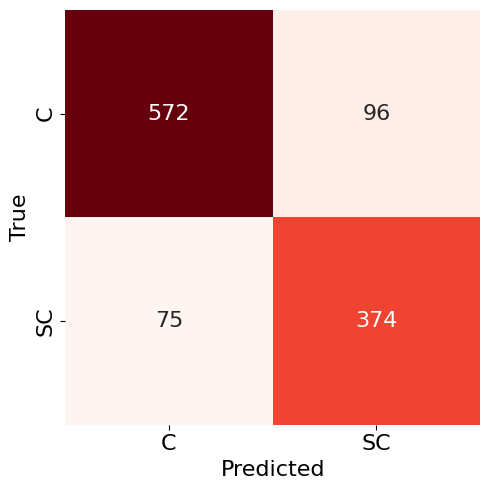

In [9]:
# Confusion matrices (train & test)

def plot_cm(cm, cmap, filename):
    plt.figure(figsize=(5,5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cbar=False, annot_kws={"size": 16}
    )
    plt.xlabel("Predicted", fontsize=16)
    plt.ylabel("True", fontsize=16)
    plt.xticks(fontsize=16); plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, format="jpg", dpi=500, bbox_inches="tight")
    plt.show()

cm_train = confusion_matrix(y_train, yhat_tr, labels=[0,1])
cm_test  = confusion_matrix(y_test,  yhat_te, labels=[0,1])

plot_cm(cm_train, "Greys", "./visual/fig_s2c.jpg")
plot_cm(cm_test,  "Reds",  "./visual/fig3b.jpg")


In [ ]:
# # Permutation importance (fixed wrapper)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.base import BaseEstimator, ClassifierMixin
# from sklearn.inspection import permutation_importance
# from sklearn.metrics import make_scorer, f1_score

# # Sklearn-compatible wrapper (has fit + predict)
# class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
#     def __init__(self, model, threshold=0.5):
#         self.model = model
#         self.threshold = threshold

#     # no-op: model is already trained
#     def fit(self, X, y=None):
#         return self

#     def predict(self, X):
#         prob = self.model.predict(X, verbose=0).ravel()
#         return (prob >= self.threshold).astype(int)

# # (Optional) subsample test for speed
# MAX_SAMPLES = 3000  # set None to use all
# if (MAX_SAMPLES is not None) and (X_test_s.shape[0] > MAX_SAMPLES):
#     rng = np.random.default_rng(42)
#     idx = rng.choice(X_test_s.shape[0], size=MAX_SAMPLES, replace=False)
#     X_pi = X_test_s[idx]
#     y_pi = np.asarray(y_test)[idx]
# else:
#     X_pi = X_test_s
#     y_pi = np.asarray(y_test)

# # Use F1-macro as the scoring target
# f1_macro_scorer = make_scorer(f1_score, average="macro")

# # Single-process to avoid TF/Keras pickling/GPU issues
# wrapper = KerasClassifierWrapper(mlp, threshold=0.5)
# perm = permutation_importance(
#     wrapper,
#     X_pi,
#     y_pi,
#     scoring=f1_macro_scorer,
#     n_repeats=8,
#     random_state=RANDOM_STATE,
#     n_jobs=1
# )

# # Build top-10 plot
# importances = pd.Series(perm.importances_mean, index=X_train.columns)
# imp_top = importances.sort_values(ascending=False).head(10)

# # Map original feature names → Feature #XXX (your style)
# feature_map = {
#     feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
#     for feat in imp_top.index
# }
# imp_top_short = imp_top.rename(index=feature_map)




In [ ]:
# plt.figure(figsize=(5.5,5))
# sns.barplot(x=imp_top_short.values, y=imp_top_short.index, palette="viridis")
# plt.xlabel("Permutation importance", fontsize=16)
# plt.ylabel("Feature", fontsize=16)

# max_val = float(max(imp_top_short.max(), 0.01))
# ticks = np.arange(0, max_val + 0.002, 0.005)
# plt.xticks(ticks, fontsize=16)
# plt.yticks(fontsize=16)

# plt.tight_layout()
# plt.savefig("./visual/fig3l.jpg", format="jpg", dpi=500, bbox_inches="tight")
# plt.show()

# lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
# display(lookup)